In [1]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from scipy.interpolate import griddata
import pyproj
from pyproj import Transformer
from datetime import datetime, timedelta
import os, fnmatch, glob
import cmocean 
import rasterio
from rasterio.plot import show
import sys
import geopy.distance
import warnings
warnings.filterwarnings('ignore')
import pandas as pd

/home/maltem/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:62: UserWarning: Pandas requires version '1.3.4' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [2]:
from TrajectoryEvaluationTemp import StatisticalEvaluation

### Evaluation against lead time

In [3]:
buoyno = [25]
startdate = datetime.strptime('2024-04-07 00:00:00','%Y-%m-%d %H:%M:%S')
enddate   = datetime.strptime('2024-04-22 00:00:00','%Y-%m-%d %H:%M:%S')
ifiletemp     = '/home/maltem/work/python/data/SvalMIZ2024/colocatedFiles/dataset_temp_full.nc'
ifiledrift    = '/home/maltem/work/python/data/SvalMIZ2024/colocatedFiles/dataset_trajectories_full.nc'

#s1 = StatisticalEvaluation(buoyno,'MET-AROMEArctic',startdate,enddate,[1,1],ifiledrift,ifiletemp)
s1 = StatisticalEvaluation(buoyno,'ECMWF-AIFS',startdate,enddate,[1,1],ifiledrift,ifiletemp)
s1.info()
s1.flag_values(rad_threshold=100)
s1.teval_cond_err(-30, 5, 5,leadno=6,cond='temp',doplot=False)
print('BIAS- as a function of Leadtime',s1.bias)
print('RMSE- as a function of Leadtime',s1.rmse)

Statistical evaluation of 1 buoys
Use of model:  ECMWF-AIFS
 -- choose model number  5
[-25 -20 -15 -10  -5   0]
BIAS- as a function of Leadtime [-1.27228079 -1.58146582 -1.31932745 -1.49254141 -1.54722001 -1.67445542]
RMSE- as a function of Leadtime [2.19516434 2.41780891 2.35628351 2.43381194 2.39100558 2.63331724]


### Plot the single buoy

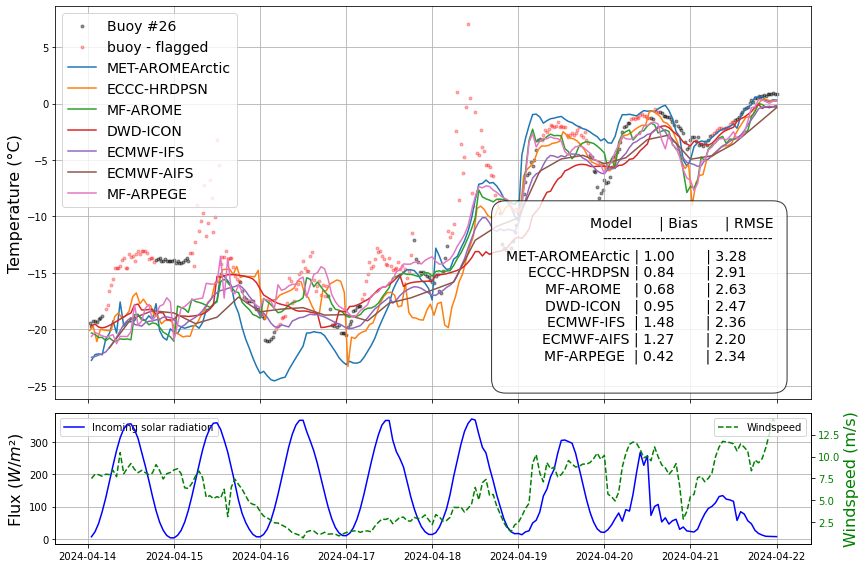

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create the figure with two subplots
fig, (ax, ax2) = plt.subplots(figsize=(12, 8), nrows=2, ncols=1, sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Time Axis limits
time_ds = s1.OMBtemp.time_ds.values  # Ensure time_ds is a NumPy array
time_min, time_max = np.min(time_ds), np.max(time_ds)
timemask = (time_ds >= np.datetime64(startdate)) & (time_ds <= np.datetime64(enddate))
filtered_indices = np.where(timemask)[0]
filtered_time_ds = time_ds[timemask]

# Plot 1: Temperature
temp_1m = np.squeeze(s1.OMBtemp.temp_1m_calibrated[buoyno, :].values)
temp_1m = temp_1m[timemask]
flag = np.squeeze(s1.OMBtemp.temp_flag[buoyno, :].values.astype(bool))
flag = flag[timemask]

ax.scatter(filtered_time_ds[~flag], temp_1m[~flag]-273.15, marker='.', color='k', label='Buoy #'+str(buoyno[0]+1), alpha=0.4)
ax.scatter(filtered_time_ds[flag], temp_1m[flag]-273.15, marker='.', color='r', label='buoy - flagged', alpha=0.3)

biasmod = []  # List to store bias values
rmsemod = []  # List to store RMSE values
model_names = []  # List to store model names

# Loop through the models to compute bias and RMSE
for mod in [0,1,2,3,4,5,6]:
    var = pd.Series(np.squeeze(s1.OMBtemp.T2M[mod, 0, buoyno, timemask]))  # Model temperature
    ax.plot(filtered_time_ds, var.interpolate(method='linear').to_numpy()-273.15, label=s1.OMBtemp.model[mod].values)
    
    # Compute bias and RMSE for the current model
    biasmod.append(np.nanmean(temp_1m[~flag] - var.to_numpy()[~flag]))  # Bias for non-flagged values
    rmsemod.append(np.sqrt(np.nanmean((temp_1m[~flag] - var.to_numpy()[~flag]) ** 2)))  # RMSE for non-flagged values
    model_names.append(s1.OMBtemp.model[mod].values)  # Append model name

# Format the table with alignment for each column
table_text = "Model      | Bias      | RMSE\n"
table_text += "-" * 35 + "\n"
for i, model in enumerate(model_names):
    table_text += f"{model:<10} | {biasmod[i]:<10.2f} | {rmsemod[i]:<10.2f}\n"

# Add the text box for the table in the lower right of the upper plot (ax)
props = dict(boxstyle='round,pad=1', facecolor='white', alpha=0.8)  # Rounded edges
ax.text(0.95, 0.05, table_text, transform=ax.transAxes, fontsize=14, verticalalignment='bottom', horizontalalignment='right', bbox=props)

#var = pd.Series(np.squeeze(s1.OMBtemp.T2M[0, 4, buoyno, timemask]))  # Model temperature
#ax.plot(filtered_time_ds, var.interpolate(method='linear').to_numpy()-273.15,'C0',linestyle='--', label=s1.OMBtemp.model[0].values)
    

ax.set_ylabel("Temperature (°C)",fontsize=16)
ax.legend(fontsize='14',loc='upper left')
ax.grid()

# Plot 2: Fluxes
flux_var = np.squeeze(s1.OMBtemp.ssdr[0, 0, buoyno, :].values)
flux_var = pd.Series(flux_var[timemask])

ax2.plot(filtered_time_ds, flux_var.interpolate(method='linear').to_numpy(), label="Incoming solar radiation", color='blue', linestyle='-', zorder=10)
ax2.set_ylabel("Flux ($W / m²$)",fontsize=16)
ax2.grid()

# Wind Speed on the second Y-axis (right side)
U_var = np.squeeze(s1.OMBtemp.U10M[0, 0, buoyno, :].values)
V_var = np.squeeze(s1.OMBtemp.V10M[0, 0, buoyno, :].values)
windspeed = pd.Series(np.sqrt(U_var**2 + V_var**2))
windspeed = windspeed[timemask]

ax2_right = ax2.twinx()  # Create a second Y-axis for windspeed
ax2_right.plot(filtered_time_ds, windspeed.interpolate(method='linear').to_numpy(), label="Windspeed", color='green', linestyle='--', zorder=5)
ax2_right.set_ylabel("Windspeed (m/s)", color='green',fontsize=16)
ax2_right.tick_params(axis='y', labelcolor='green')

# Legends for both y-axes
ax2.legend(loc='upper left')
ax2_right.legend(loc='upper right')

# Finalize layout
fig.tight_layout()
plt.show()


OMBtemp